# Aircraft Engine Safety Risk Prediction
## Data Preparation and Exploratory Analysis

This notebook performs structured data preparation and exploratory analysis 
for the NASA C-MAPSS turbofan engine dataset (FD001 and FD004).

### Objectives
1. Load multi-condition engine datasets
2. Validate structure and integrity
3. Create Remaining Useful Life (RUL) labels
4. Analyze engine cycle distribution
5. Inspect operating regimes
6. Perform initial sensor stability screening

This establishes a clean foundation for predictive safety modeling.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

# Absolute base directory (stable)
BASE_DIR = Path(r"C:\Users\Kal\aircraft-engine-safety-risk-prediction")

DATA_DIR = BASE_DIR / "data" / "raw" / "CMAPSSData"

## 1. Load C-MAPSS Datasets

We use:

- FD001 (single operating condition)
- FD004 (multiple operating conditions + multiple fault modes)

FD004 better represents real airline fleet complexity.

In [2]:
columns = ["unit", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

fd001_train = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None)
fd004_train = pd.read_csv(DATA_DIR / "train_FD004.txt", sep=r"\s+", header=None)
fd004_test  = pd.read_csv(DATA_DIR / "test_FD004.txt",  sep=r"\s+", header=None)
rul_fd004   = pd.read_csv(DATA_DIR / "RUL_FD004.txt",   sep=r"\s+", header=None)

fd001_train.columns = columns
fd004_train.columns = columns
fd004_test.columns  = columns
rul_fd004.columns   = ["RUL_end"]

print("FD001 train:", fd001_train.shape)
print("FD004 train:", fd004_train.shape)
print("FD004 test :", fd004_test.shape)

FD001 train: (20631, 26)
FD004 train: (61249, 26)
FD004 test : (41214, 26)


## 2. Basic Data Validation

We verify:
- Null values
- Duplicate rows
- Number of engines
- Cycle ranges

In [3]:
def basic_checks(df, name):
    print(f"\n{name}")
    print("Null values:", df.isna().sum().sum())
    print("Duplicates:", df.duplicated().sum())
    print("Unique engines:", df["unit"].nunique())
    print("Cycle range:", df["cycle"].min(), "to", df["cycle"].max())

basic_checks(fd001_train, "FD001 TRAIN")
basic_checks(fd004_train, "FD004 TRAIN")


FD001 TRAIN
Null values: 0
Duplicates: 0
Unique engines: 100
Cycle range: 1 to 362

FD004 TRAIN
Null values: 0
Duplicates: 0
Unique engines: 249
Cycle range: 1 to 543


## 3. Create Remaining Useful Life (RUL)

For training data:
RUL = max_cycle_per_engine − current_cycle

This transforms raw degradation logs into supervised learning format.

In [4]:
def add_rul_training(df):
    max_cycle = df.groupby("unit")["cycle"].max().rename("max_cycle")
    df = df.join(max_cycle, on="unit")
    df["RUL"] = df["max_cycle"] - df["cycle"]
    return df.drop(columns=["max_cycle"])

fd001_train = add_rul_training(fd001_train)
fd004_train = add_rul_training(fd004_train)

fd001_train[["unit","cycle","RUL"]].head()

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


## 4. Label FD004 Test Set

Test engines stop before failure.
NASA provides RUL at last recorded cycle.

RUL at cycle =
RUL_end + (max_cycle − current_cycle)

In [5]:
def add_rul_test(df_test, rul_end):
    max_cycle = df_test.groupby("unit")["cycle"].max().rename("max_cycle").reset_index()
    rul_end = rul_end.copy()
    rul_end["unit"] = np.arange(1, len(rul_end) + 1)

    merged = df_test.merge(max_cycle, on="unit").merge(rul_end, on="unit")
    merged["RUL"] = merged["RUL_end"] + (merged["max_cycle"] - merged["cycle"])
    return merged.drop(columns=["max_cycle", "RUL_end"])

fd004_test = add_rul_test(fd004_test, rul_fd004)


## 5. Engine Life Distribution

We analyze maximum cycles per engine.
This reflects degradation variability across fleet.

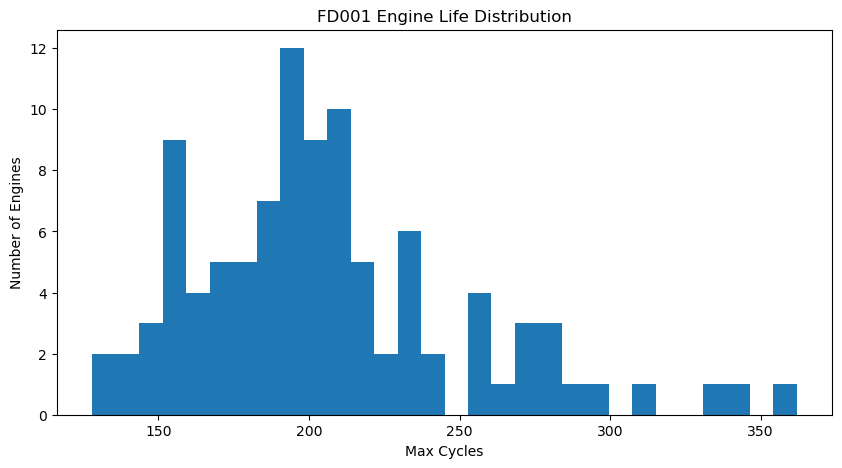

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


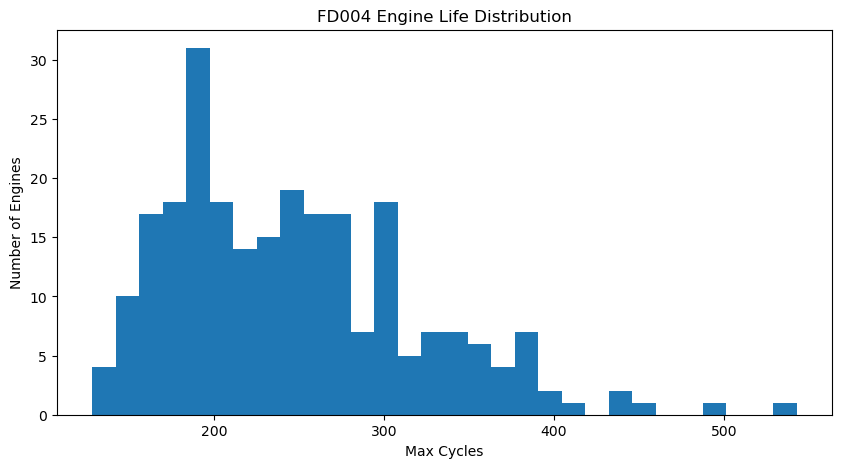

count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: cycle, dtype: float64


In [6]:
def plot_cycle_distribution(df, title):
    max_cycles = df.groupby("unit")["cycle"].max()
    plt.hist(max_cycles, bins=30)
    plt.title(title)
    plt.xlabel("Max Cycles")
    plt.ylabel("Number of Engines")
    plt.show()
    print(max_cycles.describe())

plot_cycle_distribution(fd001_train, "FD001 Engine Life Distribution")
plot_cycle_distribution(fd004_train, "FD004 Engine Life Distribution")

## 6. Operating Regime Visualization (FD004)

Multiple operating regimes simulate real-world variability 
such as altitude, throttle, and environmental conditions.

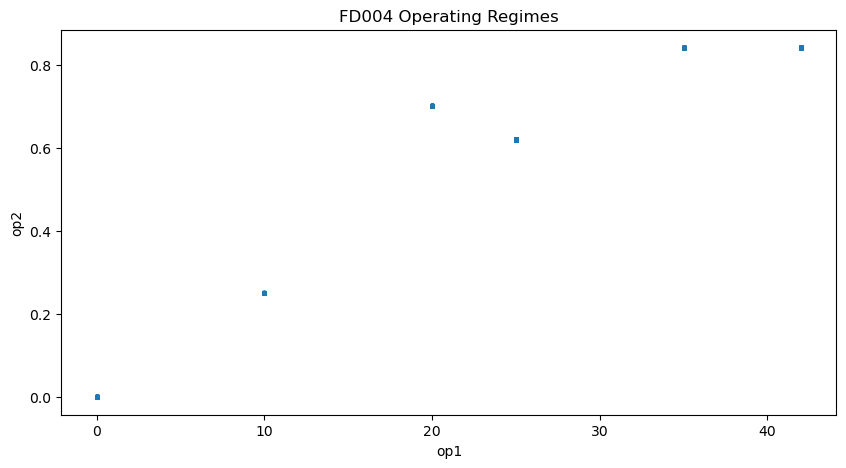

In [7]:
sample = fd004_train.sample(5000, random_state=42)

plt.scatter(sample["op1"], sample["op2"], s=5, alpha=0.3)
plt.title("FD004 Operating Regimes")
plt.xlabel("op1")
plt.ylabel("op2")
plt.show()

## 7. Sensor Variance Screening

Low-variance sensors often contain limited predictive signal.
We compute variance for initial screening.

In [8]:
sensor_cols = [f"s{i}" for i in range(1, 22)]
variance_table = fd004_train[sensor_cols].var().sort_values()

variance_table.head()

s16     0.000022
s10     0.016302
s15     0.563061
s11    10.520237
s5     13.125202
dtype: float64

## Sensor Screening

We examine sensor variance and correlation with RUL to identify low-information sensors that may be removed during feature engineering.book.

In [9]:
# Sensor columns
sensor_cols = [f"s{i}" for i in range(1, 22)]

def sensor_screening(df, name):
    print(f"\n{name}")

    # Variance
    variance = df[sensor_cols].var().sort_values()
    print("\nLowest variance sensors:")
    print(variance.head(5))

    # Correlation with RUL
    corr = df[sensor_cols + ["RUL"]].corr()["RUL"].drop("RUL").abs().sort_values()
    print("\nLowest correlation with RUL:")
    print(corr.head(5))

# Run screening
sensor_screening(fd001_train, "FD001")
sensor_screening(fd004_train, "FD004")


FD001

Lowest variance sensors:
s19    0.000000e+00
s18    0.000000e+00
s16    2.422479e-28
s10    2.172333e-25
s5     1.152399e-23
dtype: float64

Lowest correlation with RUL:
s6     0.128348
s14    0.306769
s9     0.390102
s13    0.562569
s8     0.563968
Name: RUL, dtype: float64

FD004

Lowest variance sensors:
s16     0.000022
s10     0.016302
s15     0.563061
s11    10.520237
s5     13.125202
dtype: float64

Lowest correlation with RUL:
s6     0.001349
s7     0.001429
s13    0.001501
s12    0.001639
s5     0.001679
Name: RUL, dtype: float64


## 8. Save Processed Datasets

After data preparation and RUL labeling, we save the cleaned datasets
to the `data/processed/` directory so that later notebooks can load
them directly for feature engineering and modeling.

In [10]:
from pathlib import Path

PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

fd001_train.to_csv(PROCESSED_DIR / "fd001_train_labeled.csv", index=False)
fd004_train.to_csv(PROCESSED_DIR / "fd004_train_labeled.csv", index=False)
fd004_test.to_csv(PROCESSED_DIR / "fd004_test_labeled.csv", index=False)

print("Saved datasets to:", PROCESSED_DIR)

Saved datasets to: C:\Users\Kal\aircraft-engine-safety-risk-prediction\data\processed


# Summary

This notebook completed the initial data preparation stage for the
Aircraft Engine Safety Risk Prediction project using the NASA C-MAPSS dataset.

Completed tasks:

✔ Loaded FD001 and FD004 engine degradation datasets  
✔ Validated dataset structure and integrity  
✔ Generated Remaining Useful Life (RUL) labels for training and test sets  
✔ Analyzed engine life-cycle distributions  
✔ Visualized operating regimes for multi-condition dataset (FD004)  
✔ Performed initial sensor variance screening  
✔ Saved cleaned and labeled datasets to `data/processed/` for downstream modeling

These processed datasets will be used in the next stage of the pipeline.

## Next Stage

The next notebook will focus on:

• Feature engineering  
• Operating-condition normalization  
• Time-series sequence generation  
• Preparing input tensors for LSTM / GRU models

This step prepares the data for deep learning–based Remaining Useful Life prediction.